<img src="https://api.platform.softwareone.com/public/v1/public-catalog/vendor-profiles/VND-5970-8835/icon" width="250" />

# Delivery Promise Optimization - Olist Store

Olist shows customers a delivery date at checkout that is typically 23 days, while orders arrive in around 10. This analysis asks:

- **Does the gap between estimated and delivered dates vary a lot based on distance or season?**
- **What does a broken promise cost in review score, and what does extra padding days bring?**
- **What should the promised date actually be, and what does Olist gain and give up by keeping the current one?**

## Findings

- Delivery got faster over 2018 while promises didn't follow: the late rate falls to 4.5% in the June-October test window, so the padding was calibrated for how slow Olist used to be.
- Late delivery is very costly - 2/3 of the very late orders (+5 days) were rated with 1 review score, while having more padding plateaued the scores after 7-16 days interval.
- LightGBM quantile regression model with settings alpha=0.9 achieves typical promises of ~18 days at 3.4% late rate vs Olist's 21 days at 4.5% on the test dataset.
- The most important features were destination state, distance and purchase month.

**Recommendation:** use the model with p90 settings as it improves both measures at the same time, or we can prioritize less lateness or shorter paddings.

## Scope

This dataset can be used to answer several other questions: seller quality, category performance, freight economics, and repeat purchase behaviour...

In [1]:
! pip install -q optuna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, subprocess
from pathlib import Path
import re
from lightgbm import LGBMRegressor
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_pinball_loss
import json
import zipfile, urllib.request

In [3]:
REPO_URL  = "https://github.com/doniyor117/olist-store-analysis.git"
REPO_NAME = "olist-store-analysis"

def find_root(start):
    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p
    return None

ROOT = find_root(Path.cwd())
if ROOT is None:                                  # not inside the repo
    if not (Path.cwd() / REPO_NAME).exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    ROOT = (Path.cwd() / REPO_NAME).resolve()

FIGURES_DIR = ROOT / "01-delivery-estimates" / "figures"
MODELS_DIR  = ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)

ROOT: /content/olist-store-analysis


# *Importing The Dataset*:

In [4]:
LOCAL = os.path.join(ROOT, "data", "raw")
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/olistbr/brazilian-ecommerce"

try:
    import kagglehub
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
except Exception:
    path = LOCAL
    if not os.path.exists(os.path.join(path, "olist_orders_dataset.csv")):
        os.makedirs(path, exist_ok=True)
        zp, _ = urllib.request.urlretrieve(KAGGLE_URL)
        zipfile.ZipFile(zp).extractall(path)

print("Path to ecommerce dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to ecommerce dataset files: /kaggle/input/brazilian-ecommerce


In [5]:
tables = os.listdir(path)
tables

['olist_customers_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_order_payments_dataset.csv']

# *Creating **dataset** and **metadata dicts** of tables:*

The ***dataset*** and ***metadata_catalog*** keeps all tables as key-values where **key** is a table name and **value** is DataFrame and metadata of tables respectively.

In [6]:
def create_metadata_cat(df):
  return pd.DataFrame({
      "Columns": df.columns,
      "Non-Null Count": df.notnull().sum().values,
      "Null Count": df.isnull().sum().values,
      "Null %": (df.isnull().mean() * 100).round(2),
      "Dtype": df.dtypes.astype(str),
      "Unique Values": df.nunique().values,
      "Example Value": [df[df[column].notnull()][column].iloc[0] for column in df.columns]
  }).reset_index(drop=True)

In [7]:
dataset = {}
metadata_catalog = {}

for table in tables:
  table_name = table.strip().split(sep=".")[0]
  table_name = re.sub("olist_|_dataset", "", table_name)
  file_path = path + "/" + table

  df = pd.read_csv(file_path)

  dataset[table_name] = df
  metadata_catalog[table_name] = create_metadata_cat(df)

---

# ***General Summary** of all tables of the dataset:*

In [8]:
summary_table = []

for table_name, df in dataset.items():
  total_count = len(df)
  missing_count = df.isnull().any(axis=1).sum()
  missing_ratio = f"{(missing_count / total_count + 1e-5):.2%}"
  top_null_rows = None

  if missing_count != 0:
    nulls_by_rows = dataset[table_name].isnull().sum().sort_values(ascending=False)
    top_null_rows = nulls_by_rows[nulls_by_rows > 0].iloc[:3].index.to_list()
    top_null_rows = ", ".join(top_null_rows)
  else:
    missing_count = "0 🎉️"
    missing_ratio = "0%"

  summary_table.append({
      "Table Name": table_name,
      "Total Rows": total_count,
      "Rows With Missing Values": missing_count,
      "Missing %": missing_ratio,
      "Top Rows With Missing Values": top_null_rows
  })

summary_df = pd.DataFrame(summary_table)
summary_df

,Table Name,Total Rows,Rows With Missing Values,Missing %,Top Rows With Missing Values
0,customers,99441,0 🎉️,0%,None
1,sellers,3095,0 🎉️,0%,None
2,order_reviews,99224,89385,90.09%,"review_comment_title, review_comment_message"
3,order_items,112650,0 🎉️,0%,None
4,products,32951,611,1.86%,"product_category_name, product_description_len..."
5,geolocation,1000163,0 🎉️,0%,None
6,product_category_name_translation,71,0 🎉️,0%,None
7,orders,99441,2980,3.00%,"order_delivered_customer_date, order_delivered..."
8,order_payments,103886,0 🎉️,0%,None


> All the tables seem like complete except three of them: reviews, products, and orders themselves. reviews table has the most null values, and my guess is that people rate but usually don't leave comments - and it also depends on the score...


---

# *Exploring and Visualizing tables with missing values to find any **anomalies** or **relationships*** :

In [9]:
sus_tables = ["order_reviews", "products", "orders"]

## **order_reviews** table:

![](https://raw.githubusercontent.com/doniyor117/olist-store-analysis/main/01-delivery-estimates/figures/order_reviews_null_analysis.png)

_Each bar is 100% of that month's reviews. Orange = comment present, blue = missing.
Read the *shares* within a bar, not bar heights. Heights are fixed at 1.0 by `multiple="fill"`._

### Findings:

> Neither comment field is "missing" in a way that needs fixing.
>
> `review_comment_title` is essentially absent before April 2018, then suddenly jumps to steady ~40%. This suggest that this feature was added later instead of people ignoring to fill in. A structural missingness.

> `review_comment_message` is missing in a score-dependent way: 77% of 1-star reviewers write something, versus 36% of 5-star. Dissatisfied customers had something to say while satisfied ones don't bother writing. `has_comment` flag would be a good feature.

> Both columns are dropped as out of scope: this analysis uses `review_score`, which is 100% complete. The new boolean column is left for the follow up projects.

### Decision:

> Drop the two columns and create a new feature called `has_comment`.

In [10]:
dataset['order_reviews']['has_comment'] = dataset['order_reviews']['review_comment_message'].notnull()
dataset['order_reviews'] = dataset['order_reviews'].drop(columns=['review_comment_title', 'review_comment_message'])
dataset['order_reviews'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
 5   has_comment              99224 non-null  bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 3.9+ MB


---

## **products** table:

In [11]:
metadata_catalog['products']

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,product_id,32951,0,0.00,object,32951,1e9e8ef04dbcff4541ed26657ea517e5
1,product_category_name,32341,610,1.85,object,73,perfumaria
2,product_name_lenght,32341,610,1.85,float64,66,40.0
3,product_description_lenght,32341,610,1.85,float64,2960,287.0
4,product_photos_qty,32341,610,1.85,float64,19,1.0
5,product_weight_g,32949,2,0.01,float64,2204,225.0
6,product_length_cm,32949,2,0.01,float64,99,16.0
7,product_height_cm,32949,2,0.01,float64,102,10.0
8,product_width_cm,32949,2,0.01,float64,95,14.0


In [12]:
dataset[sus_tables[1]].isnull().sum(axis=1).value_counts()

,count
0,32340
4,610
8,1


### Findings:

> 610 products (1.85%) are missing among mostly 4 descriptive attributes: `category`, `name`
and `description length`, `photo count`, while dimensional data is present.
Values missing as a block points to a pipeline gap rather than random loss.

> Category columns could be used for this or following projects. The three
listing-quality columns will be dropped as out of scope. Weight and dimensions,
which this analysis does use, are missing for only 2 products.

### Decision:

> Fill category column nulls with `unknown`, and drop the 3 listing-quality columns.

In [13]:
dataset['products'] = dataset['products'].drop(columns=['product_photos_qty', 'product_name_lenght', 'product_description_lenght'])
dataset['products']['product_category_name'] = dataset['products']['product_category_name'].fillna('unknown')
dataset['products'] = dataset['products'].dropna()
dataset['products'].head(5)

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,625.0,20.0,17.0,13.0


---

## **orders** table:

In [14]:
timestamps = ["order_approved_at", "order_delivered_carrier_date",
              "order_delivered_customer_date"]

null_by_status = dataset['orders'].groupby("order_status")[timestamps].apply(lambda x: x.isnull().mean().round(2))

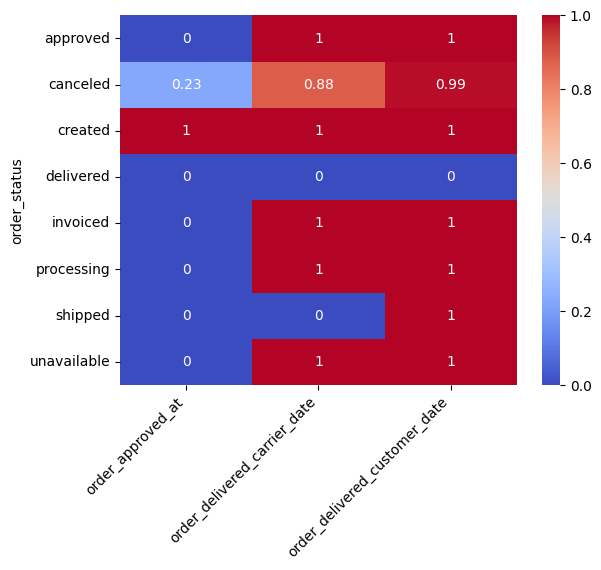

In [15]:
sns.heatmap(null_by_status, annot=True, vmin=0, vmax=1, cmap="coolwarm")
plt.xticks(rotation=45, ha="right")

plt.gcf().savefig(os.path.join(FIGURES_DIR, "orders_table_null_heatmap.png"), dpi=200, bbox_inches='tight')
plt.show()

Each cell shows the raltionships between order status and its timeline.

0 = always present (meaning if one exist another one is there too), 1 = always missing.
Columns run left to right in the order the events happen.

### Findings:

> Missing timestamps in `orders` are structural, not data loss: each status is
missing exactly the stages it hasn't reached. `created` has no timestamps,
`shipped` has a carrier handover but no customer delivery, `delivered` has all
three. `canceled` is the only mixed case because some orders were cancelled in different phases.

### Decision:

> This analysis therefore filters to `order_status == "delivered"`, where all
three timestamps are present, while omitting unfinished orders.

In [16]:
dataset['orders'] = dataset['orders'][dataset['orders'].order_status == 'delivered']
dataset['orders'] = dataset['orders'].dropna(
    subset=["order_approved_at", "order_delivered_carrier_date",
            "order_delivered_customer_date"])
metadata_catalog['orders'] = create_metadata_cat(dataset['orders'])
metadata_catalog['orders']

,Columns,Non-Null Count,Null Count,Null %,Dtype,Unique Values,Example Value
0,order_id,96455,0,0.0,object,96455,e481f51cbdc54678b7cc49136f2d6af7
1,customer_id,96455,0,0.0,object,96455,9ef432eb6251297304e76186b10a928d
2,order_status,96455,0,0.0,object,1,delivered
3,order_purchase_timestamp,96455,0,0.0,object,95933,2017-10-02 10:56:33
4,order_approved_at,96455,0,0.0,object,88266,2017-10-02 11:07:15
5,order_delivered_carrier_date,96455,0,0.0,object,80094,2017-10-04 19:55:00
6,order_delivered_customer_date,96455,0,0.0,object,95643,2017-10-10 21:25:13
7,order_estimated_delivery_date,96455,0,0.0,object,445,2017-10-18 00:00:00


---

---

# *Analyzing and Exploring **<mark>Delivery Times:***


### Aggregating and merging tables we need in our analysis:

In [17]:
geo = (dataset['geolocation']
       .groupby(by='geolocation_zip_code_prefix')[
           ['geolocation_lat', 'geolocation_lng']
           ].median().reset_index())
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 445.8 KB


> Aggregating `order_items` table to one line per order before merging with `orders` table, otherwise we are gonna have 4 rows for orders with 4 items in merged table which weights results by basket size when every mean, median, or rate is found:

In [18]:
items_agg = dataset['order_items'].groupby(by='order_id').agg(
    seller_id=('seller_id', 'first'),
    product_id=('product_id', 'first'),
    n_sellers=('seller_id', 'nunique'),
    n_items=('order_item_id', 'count'),
    freight_value=('freight_value', 'sum'),
    price=('price', 'sum')
).reset_index()

items_agg.head()

,order_id,seller_id,product_id,n_sellers,n_items,freight_value,price
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,4244733e06e7ecb4970a6e2683c13e61,1,1,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,e5f2d52b802189ee658865ca93d83a8f,1,1,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,c777355d18b72b67abbeef9df44fd0fd,1,1,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,7634da152a4610f1595efa32f14722fc,1,1,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,ac6c3623068f30de03045865e4e10089,1,1,18.14,199.90


> Only taking the first where orders have more than one sellers, because it is responsible to only ~1.3 percent of the whole orders:

In [19]:
n_sellers = dataset['order_items'].groupby('order_id').seller_id.nunique()
print("Orders with more that one sellers:", round((n_sellers > 1).mean() * 100, 3))

Orders with more that one sellers: 1.295


---

In [20]:
ord_time_cols = dataset['orders'][[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]

for t_col in ord_time_cols:
  dataset['orders'][t_col] = pd.to_datetime(dataset['orders'][t_col])

In [21]:
orders_agg = (dataset['orders']
                    .merge(dataset['customers'], on='customer_id', how='inner')
                    .merge(items_agg, on='order_id', how='inner')
                    .merge(dataset['sellers'], on='seller_id', how='inner')
                    .merge(dataset['products'], on='product_id', how='inner')
                    )

orders_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96439 entries, 0 to 96438
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96439 non-null  object        
 1   customer_id                    96439 non-null  object        
 2   order_status                   96439 non-null  object        
 3   order_purchase_timestamp       96439 non-null  datetime64[ns]
 4   order_approved_at              96439 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96439 non-null  datetime64[ns]
 6   order_delivered_customer_date  96439 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96439 non-null  datetime64[ns]
 8   customer_unique_id             96439 non-null  object        
 9   customer_zip_code_prefix       96439 non-null  int64         
 10  customer_city                  96439 non-null  object        
 11  customer_state 

Adding seller and cutomer geolocation records:

In [22]:
orders_agg = orders_agg.merge(
    geo.rename(columns={
        'geolocation_zip_code_prefix':'customer_zip_code_prefix',
        'geolocation_lat':'customer_lat',
        'geolocation_lng':'customer_lng'
        }),
    on='customer_zip_code_prefix', how='left'
    )

orders_agg = orders_agg.merge(
    geo.rename(columns={
        'geolocation_zip_code_prefix':'seller_zip_code_prefix',
        'geolocation_lat':'seller_lat',
        'geolocation_lng':'seller_lng'
        }),
    on='seller_zip_code_prefix', how='left'
    )

null_pct = orders_agg[['seller_lat', 'customer_lat']].isnull().mean() * 100
print("Null values after merge (%):")
print(null_pct.round(2))

Null values after merge (%):
seller_lat      0.22
customer_lat    0.27
dtype: float64


> Some zip codes from customers or sellers are not in our geolocation table so we dropped them:

In [23]:
print("Before dropping nulls: ", len(orders_agg))
orders_agg = orders_agg.dropna()
print("After dropping nulls: ", len(orders_agg))

Before dropping nulls:  96439
After dropping nulls:  95961


In [24]:
orders_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95961 entries, 0 to 96438
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       95961 non-null  object        
 1   customer_id                    95961 non-null  object        
 2   order_status                   95961 non-null  object        
 3   order_purchase_timestamp       95961 non-null  datetime64[ns]
 4   order_approved_at              95961 non-null  datetime64[ns]
 5   order_delivered_carrier_date   95961 non-null  datetime64[ns]
 6   order_delivered_customer_date  95961 non-null  datetime64[ns]
 7   order_estimated_delivery_date  95961 non-null  datetime64[ns]
 8   customer_unique_id             95961 non-null  object        
 9   customer_zip_code_prefix       95961 non-null  int64         
 10  customer_city                  95961 non-null  object        
 11  customer_state      

## Checking for patterns in estimated delivery days:

In [25]:
orders_agg['estimated_delivery_days'] = (
    orders_agg['order_estimated_delivery_date'] -
    orders_agg['order_purchase_timestamp']
    ).dt.days

In [26]:
for st in orders_agg.customer_state.unique()[:3]:
    subset = orders_agg[orders_agg.customer_state == st]
    print(f'State: {st}')
    print(subset['estimated_delivery_days'].value_counts(normalize=True).head(8).round(3).to_dict())
    print('\n')

for ct in orders_agg.customer_city.unique()[:3]:
    subset = orders_agg[orders_agg.customer_city == ct]
    print(f'City: {ct}')
    print(subset['estimated_delivery_days'].value_counts(normalize=True).head(8).round(3).to_dict())
    print('\n')

State: SP
{19: 0.071, 18: 0.057, 12: 0.056, 17: 0.054, 21: 0.053, 20: 0.051, 13: 0.05, 22: 0.05}


State: BA
{30: 0.078, 29: 0.075, 28: 0.074, 27: 0.07, 31: 0.066, 32: 0.065, 26: 0.06, 25: 0.055}


State: GO
{28: 0.087, 27: 0.086, 25: 0.075, 26: 0.068, 30: 0.061, 22: 0.061, 29: 0.059, 23: 0.059}


City: sao paulo
{12: 0.07, 19: 0.061, 13: 0.059, 17: 0.056, 15: 0.053, 18: 0.051, 21: 0.049, 11: 0.048}


City: barreiras
{25: 0.118, 29: 0.118, 30: 0.078, 28: 0.078, 26: 0.078, 27: 0.078, 31: 0.059, 22: 0.059}


City: vianopolis
{26: 0.333, 24: 0.333, 33: 0.333}




> Each number shown here (e.g. 19: 0.071) means in what rate that padding days are used for the specific state. Here we can see static numbers are not used for per state or city (which probably should dominate others with >0.5 rate), so assuming fixed number per destination is wrong

---

**Observed** differences between delivered date and estimated delivery date:

In [27]:
orders_agg['delivered_in_days'] = (
    orders_agg['order_delivered_customer_date'] -
    orders_agg['order_purchase_timestamp']
).dt.days

orders_agg['delivery_buffer_days'] = orders_agg['estimated_delivery_days'] - orders_agg['delivered_in_days']

print(orders_agg['delivery_buffer_days'].describe())

count    95961.000000
mean        11.283386
std         10.193174
min       -189.000000
25%          7.000000
50%         12.000000
75%         16.000000
max        146.000000
Name: delivery_buffer_days, dtype: float64


In [28]:
print("Median of promises:", orders_agg.estimated_delivery_days.median())
print("Median of deliveries:", orders_agg.delivered_in_days.median())
print("Median of gaps:", (orders_agg.estimated_delivery_days - orders_agg.delivered_in_days).median())
print(f"Late delivery rate (%): {(orders_agg['delivery_buffer_days'] < 0).mean() * 100:.2f}%")

Median of promises: 23.0
Median of deliveries: 10.0
Median of gaps: 12.0
Late delivery rate (%): 7.57%


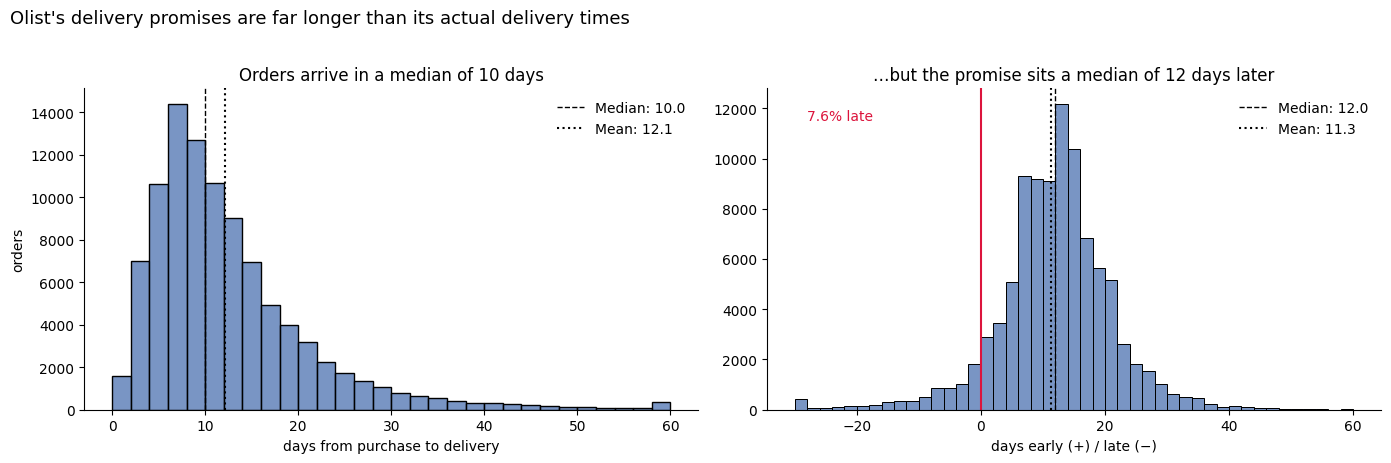

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

med_actual = orders_agg.delivered_in_days.median()
mean_actual = orders_agg.delivered_in_days.mean()

med_buffer = orders_agg.delivery_buffer_days.median()
mean_buffer = orders_agg.delivery_buffer_days.mean()

late = (orders_agg.delivery_buffer_days < 0).mean() * 100

# Left Plot: Actual Delivery Time
sns.histplot(orders_agg.delivered_in_days.clip(upper=60),
             bins=range(0, 62, 2), ax=axes[0], color="#4c72b0")
axes[0].axvline(med_actual, color="black", ls="--", lw=1, label=f"Median: {med_actual:.1f}")
axes[0].axvline(mean_actual, color="black", ls=":", lw=1.5, label=f"Mean: {mean_actual:.1f}")
axes[0].set(title=f"Orders arrive in a median of {med_actual:.0f} days",
            xlabel="days from purchase to delivery", ylabel="orders")
axes[0].legend(frameon=False)

# Right Plot: Delivery Buffer (Early/Late)
sns.histplot(orders_agg.delivery_buffer_days.clip(-30, 60),
             bins=range(-30, 62, 2), ax=axes[1], color="#4c72b0")
axes[1].axvline(0, color="crimson", lw=1.5)
axes[1].axvline(med_buffer, color="black", ls="--", lw=1, label=f"Median: {med_buffer:.1f}")
axes[1].axvline(mean_buffer, color="black", ls=":", lw=1.5, label=f"Mean: {mean_buffer:.1f}")
axes[1].set(title=f"…but the promise sits a median of {med_buffer:.0f} days later",
            xlabel="days early (+) / late (−)", ylabel="")
axes[1].text(-28, axes[1].get_ylim()[1]*0.9, f"{late:.1f}% late",
             color="crimson", fontsize=10)
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax)

fig.suptitle("Olist's delivery promises are far longer than its actual delivery times",
             fontsize=13, y=1.02, ha="left", x=0.01)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "observed_vs_estimated_delivery_time_histplot.png"),
            dpi=200, bbox_inches='tight')
plt.show()

> The left graph shows we have right skewed data where some ourlier orders pulled our mean value to right, so we used median instead to show a typical value instead of average.

> Orders typically arrive in 10 days but Olist puts huge 12 days buffer to keep lateness rate low. So there should be a reason for this huge padding, yet, excessively long delivery estimates might risk competitiveness against market rivals


---

In [30]:
reviews_agg = dataset['order_reviews'].groupby(by='order_id').agg({
    'review_score':'mean',
    'review_creation_date':'first',
    'has_comment':'first'
})

orders_agg = orders_agg.merge(reviews_agg, how='inner', on='order_id')
orders_agg['review_creation_date'] = pd.to_datetime(orders_agg['review_creation_date'])

orders_agg['review_delay'] = (
    orders_agg['review_creation_date']
    - orders_agg['order_delivered_customer_date'].dt.normalize()
).dt.days

orders_agg.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'seller_id', 'product_id', 'n_sellers', 'n_items',
       'freight_value', 'price', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
       'estimated_delivery_days', 'delivered_in_days', 'delivery_buffer_days',
       'review_score', 'review_creation_date', 'has_comment', 'review_delay'],
      dtype='object')

### Checking when reviews are created:

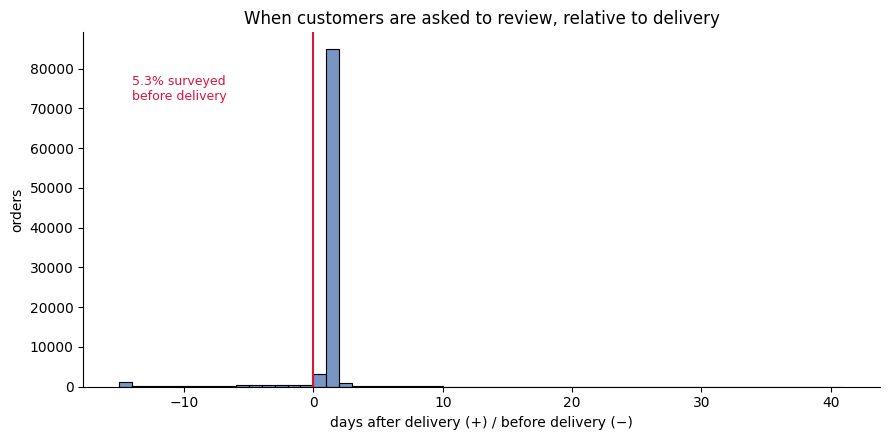

In [31]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.histplot(orders_agg.review_delay.clip(-15, 40),
             bins=range(-15, 42, 1), ax=ax, color="#4c72b0")

ax.axvline(0, color="crimson", lw=1.5)

before = (orders_agg.review_delay < 0).mean() * 100
ax.text(-14, ax.get_ylim()[1] * 0.88,
        f"{before:.1f}% surveyed\nbefore delivery",
        color="crimson", fontsize=9, va="top")

ax.set(title="When customers are asked to review, relative to delivery",
       xlabel="days after delivery (+) / before delivery (−)",
       ylabel="orders")
sns.despine(ax=ax)

plt.tight_layout()
plt.gcf().savefig(os.path.join(FIGURES_DIR, "promise_vs_reliability.png"), dpi=200, bbox_inches='tight')

> From the graph we can see that the review request or notification sent immediately after order is received, but 5.3% is done before delivery. late delivery rate was 7.6%. Maybe there are some relationships:

In [32]:
orders_agg[orders_agg['review_delay'] < 0]['delivery_buffer_days'].lt(0).mean() * 100

np.float64(94.36788496105453)

> This confirms 94% of the surveys sent before delivery were on late orders, consistent with the review notification firing when the estimated delivery date passes.


---

## *Analysing **review scores** based on delivery timeline bins:*

In [33]:
orders_agg.delivery_buffer_days.describe(percentiles=[.015, .05, .25, .5, .75, .95])

,delivery_buffer_days
count,95316.000000
mean,11.320565
std,10.122731
min,-189.000000
1.5%,-14.000000
5%,-4.000000
25%,7.000000
50%,12.000000
75%,16.000000
95%,26.000000


In [34]:
bins = [-np.inf, -5, -2, -1, 0, 7, 16, 26, np.inf]
labels = ['very late', 'late', 'slightly late', 'on-time', 'slightly early', 'early', 'very early', 'extremely early']

orders_agg['buffer_bucket'] = pd.cut(orders_agg['delivery_buffer_days'], bins=bins, labels=labels)
orders_agg.groupby(by='buffer_bucket', observed=False)[['review_score']].agg(['mean', 'size'])

review_score       
                        mean   size
buffer_bucket                      
very late           1.822472   4312
late                3.094181   1667
slightly late       3.965686   1122
on-time             4.124173   1361
slightly early      4.209293  19241
early               4.323507  44182
very early          4.322610  19164
extremely early     4.263886   4267

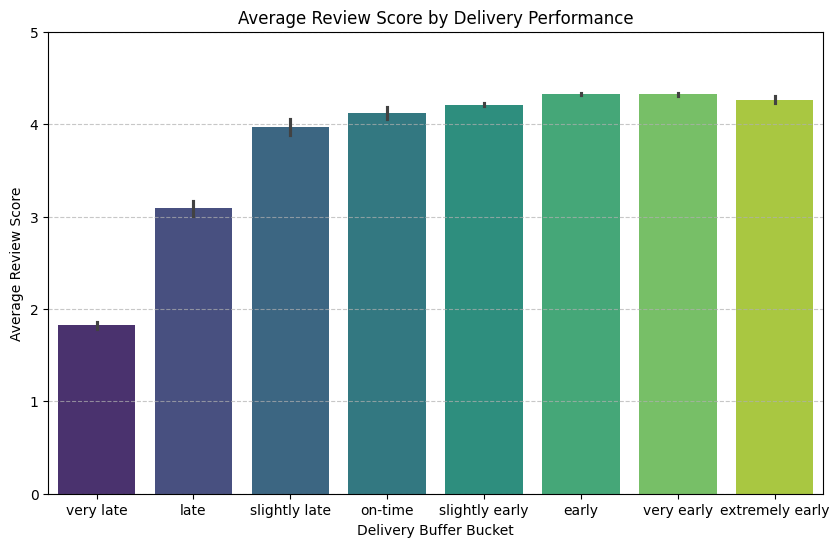

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=orders_agg, x='buffer_bucket', y='review_score', hue='buffer_bucket', palette='viridis', legend=False)

plt.title('Average Review Score by Delivery Performance')
plt.ylabel('Average Review Score')
plt.xlabel('Delivery Buffer Bucket')
plt.ylim(0, 5) # Scores are between 1 and 5
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gcf().savefig(os.path.join(FIGURES_DIR, "review_scores_by_delivery_performance.png"), dpi=200, bbox_inches='tight')
plt.show()

> The graph is showing late deliveries usually have lower scores, whereas having higher buffer of days for estimate - early deliveries score higher and it plateus after 7-16 days early delivery buffer. However this doesn't necessarily mean having higher padding result in this. For example the distance might me one of the main factors for it

### Calculating the distances using lat and lon data:

> Using haversine for calculating direct distances (as we don't have the exact road distances):

In [36]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Convert all degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula elements
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    # 6371 is the Earth's radius in kilometers
    return c * 6371

In [37]:
orders_agg['distance_km'] = haversine_vectorized(
    orders_agg.seller_lat,
    orders_agg.seller_lng,
    orders_agg.customer_lat,
    orders_agg.customer_lng
    )

orders_agg.distance_km.describe()

,distance_km
count,95316.000000
mean,600.322560
std,593.795148
min,0.000000
25%,184.556024
50%,433.724478
75%,798.023687
max,8677.859564


> Note that these are straight line distances where it might ignore roads and go straight through mountains and barriers

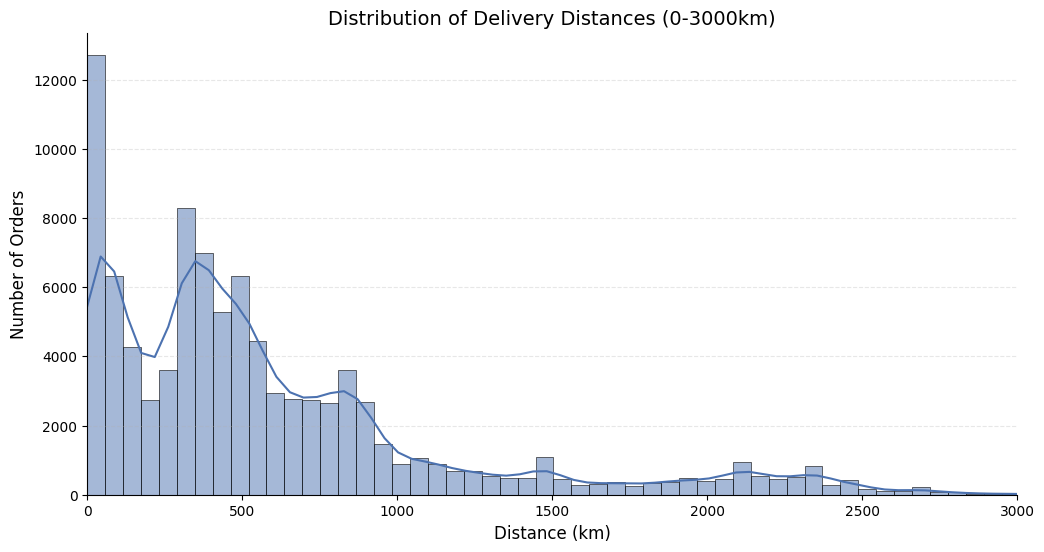

In [38]:
plt.figure(figsize=(12, 6))
# Focusing on the 0-3000km range to see the actual distribution shape
sns.histplot(data=orders_agg, x='distance_km', bins=150, kde=True, color='#4c72b0')

plt.xlim(0, 3000)
plt.title('Distribution of Delivery Distances (0-3000km)', fontsize=14)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.gcf().savefig(os.path.join(FIGURES_DIR, "delivery_distances_distribution.png"), dpi=200, bbox_inches='tight')
plt.show()

> This shows we have bimodal-ish graph were 0-130km has a big spike, and another bump between 300-550. This could be explained with Brazil's geography: sellers cluster in the southeast, so we get short intra-region deliveries plus a sparse set of long hauls to the north and northeast.


### Plotting scores by binning with both **distance quarters** and **delivery timeline**:

In [39]:
orders_agg['distance_bin'] = pd.qcut(orders_agg.distance_km, 4, labels=['Q1 short', 'Q2', 'Q3', 'Q4 long'])

plot_df = orders_agg.groupby(by=['distance_bin', 'buffer_bucket'], observed=False).review_score.agg(
    score_mean='mean', n='size', score_1_percentage=(lambda x: ((x==1).mean()*100).round(2))).reset_index()

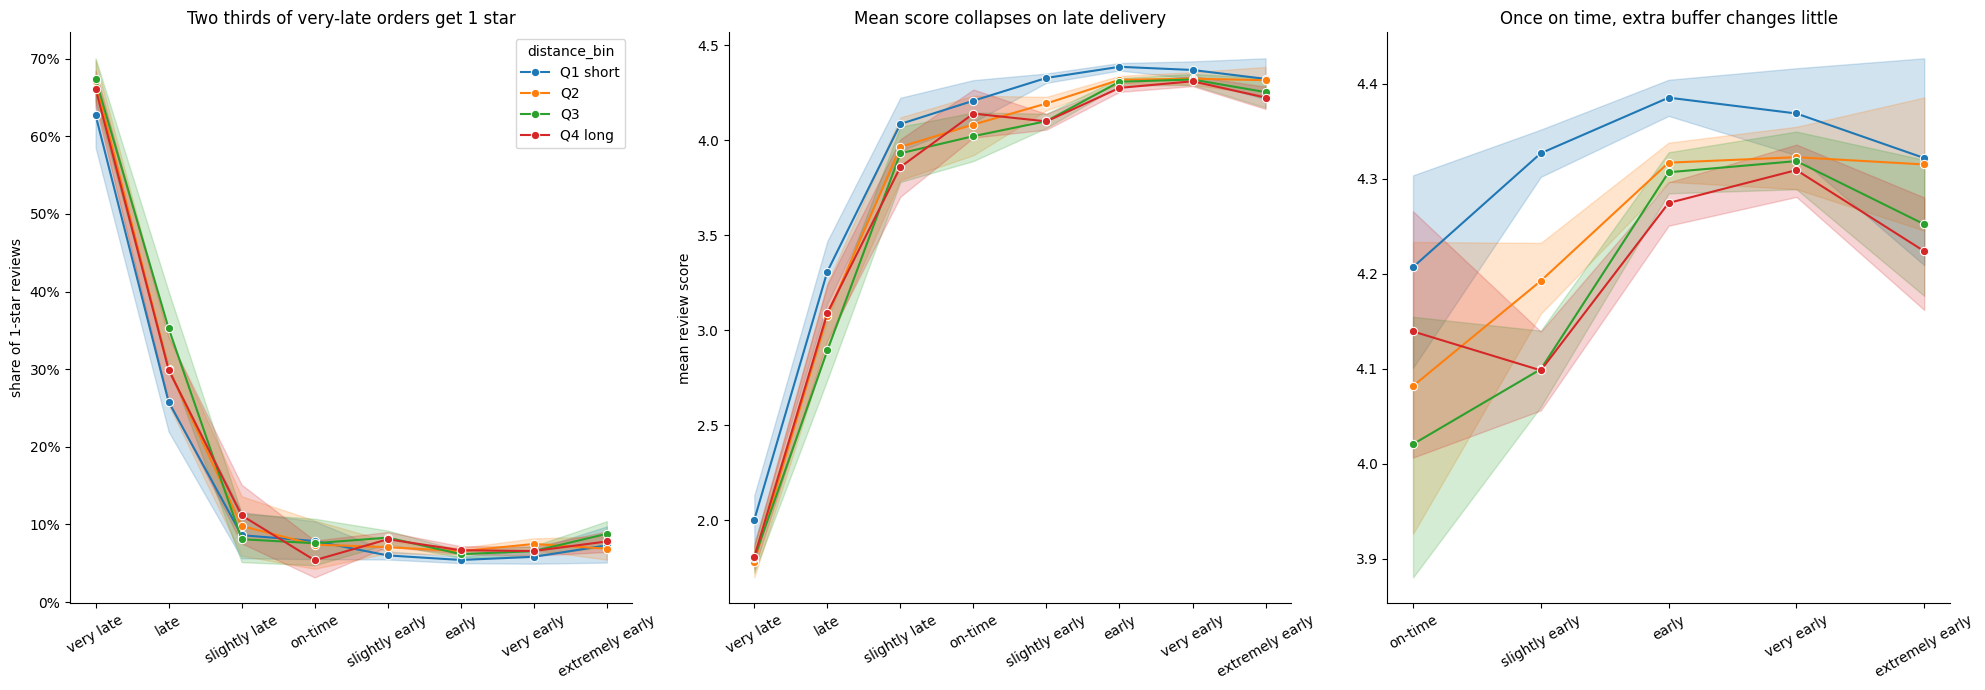

In [40]:
orders_agg['is_1star'] = (orders_agg.review_score == 1)

late_buckets = ['very late', 'late', 'slightly late']
zoom_raw = orders_agg[~orders_agg.buffer_bucket.isin(late_buckets)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1 — share of 1-star, full range
sns.lineplot(data=orders_agg, x='buffer_bucket', y='is_1star', hue='distance_bin',
             marker='o', errorbar=('ci', 95), ax=axes[0])
axes[0].set(title="Two thirds of very-late orders get 1 star",
            ylabel="share of 1-star reviews", xlabel="")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

# 2 — mean score, full range
sns.lineplot(data=orders_agg, x='buffer_bucket', y='review_score', hue='distance_bin',
             marker='o', errorbar=('ci', 95), ax=axes[1])
axes[1].set(title="Mean score collapses on late delivery", ylabel="mean review score", xlabel="")
axes[1].legend().remove()

# 3 — mean score, zoomed to on-time and earlier
sns.lineplot(data=zoom_raw, x='buffer_bucket', y='review_score', hue='distance_bin',
             marker='o', errorbar=('ci', 95), ax=axes[2])
axes[2].set(title="Once on time, extra buffer changes little", ylabel="", xlabel="")
axes[2].legend().remove()

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

plt.tight_layout()
plt.gcf().savefig(os.path.join(FIGURES_DIR, "promise_vs_reliability.png"), dpi=200, bbox_inches='tight')

### *Findings:*

As we can see, late orders tend to have very low review scores, and 2/3 of very late orders received a review score of 1.

Another interesting finding is that early orders (7-16 days prior to the promised date) have consistently high review scores among all, even higher than the scores given for on-time deliveries.

The shaded areas represent the 95% confidence interval, and early delivery has a narrower band than others, meaning the estimate is more precise - there are far more orders in that bucket. The bands for the largest buffers overlap, so we can't tell 16 days of buffer apart from 26.

Distance has less effect on the shape of the trend, even though shorter distances tend to score higher overall

So the cost of missing the estimated delivery date is severe.

---

# *Training a **model** to predict the **optimal estimated date:***

### First a measuring naive baseline state-pair estimate:

In [41]:
orders_agg['order_purchase_month'] = orders_agg['order_purchase_timestamp'].dt.strftime('%B')
orders_agg.order_purchase_month.head()

,order_purchase_month
0,October
1,July
2,August
3,November
4,February


In [42]:
cutoff = orders_agg.order_purchase_timestamp.quantile(0.8)
print(cutoff)

train_mask = orders_agg.order_purchase_timestamp < cutoff
test_mask = orders_agg.order_purchase_timestamp >= cutoff

train = orders_agg[train_mask]
test = orders_agg[test_mask]

2018-05-27 14:58:45


> Time based split is important for comparison and crucially for our model. Because training model on future date data (test dataset) is gonna leak some hints from them and model starts to cheat or cause overfitting.

In [43]:
national_p90 = train.delivered_in_days.quantile(0.9)

base = train.groupby(by=['seller_state', 'customer_state'], observed=False)['delivered_in_days'].agg(
    baseline_pred_p90=lambda x: x.quantile(0.9), n='size'
    )

base['baseline_pred_p90'] = base['baseline_pred_p90'].where(base.n >= 50, national_p90)
base

baseline_pred_p90      n
seller_state customer_state                          
AM           AL                           24.0      1
             MA                           24.0      1
             MG                           24.0      1
BA           AC                           24.0      1
             AL                           24.0      6
...                                        ...    ...
SP           RS                           28.0   2965
             SC                           28.0   1924
             SE                           41.0    158
             SP                           15.0  23705
             TO                           29.0    159

[390 rows x 2 columns]

> Baseline prediction is predicting 90 percentile of whole data per state where order are late only 10% of the time. It essentially binds specific fixed number per state. We also used national p90 for state with orders less than 50 preventing biased results.


In [44]:
print(train.delivered_in_days.mean(), test.delivered_in_days.mean())

12.986138068509678 8.269041124632816


In [45]:
orders_agg.groupby(orders_agg.order_purchase_timestamp.dt.to_period('M')).delivered_in_days.agg(['mean', 'count'])

,mean,count
order_purchase_timestamp,,
2016-09,54.000000,1
2016-10,18.843511,262
2016-12,4.000000,1
2017-01,12.020325,738
2017-02,12.391171,1631
2017-03,12.359984,2514
2017-04,14.258150,2270
2017-05,10.669334,3499
2017-06,11.480894,3088


> Overall, average delivery speed increased in test dataset period than it was before. Another finding is that delivery speed depends on season a lot (slower in winter-spring, faster in summer), but if we do head on year by year comparison of 2018 and 2017 data we can see improvement.

In [46]:
model_features = [
    'customer_state', 'seller_state',
    'distance_km',
    'freight_value', 'price',
    'n_items', 'n_sellers',
    'order_purchase_month'
]
target = 'delivered_in_days'

train_X = train[model_features].copy()
test_X = test[model_features].copy()

train_y = train[target].copy()
test_y = test[target].copy()

In [47]:
for df in [train_X, test_X]:
  for feature in ['customer_state', 'seller_state', 'order_purchase_month']:
    df[feature] = df[feature].astype('category')

Using bayesian based search method to find the best hyperparameters for the model:

In [48]:
RUN_SEARCH = False

if RUN_SEARCH:
  ALPHA = 0.9
  train_sorted = train.sort_values('order_purchase_timestamp')
  Xs = train_sorted[model_features].copy()
  ys = train_sorted[target].copy()
  for c in ['customer_state', 'seller_state', 'order_purchase_month']:
      Xs[c] = Xs[c].astype('category')

  tscv = TimeSeriesSplit(n_splits=3)

  def objective(trial):
      params = dict(
          objective='quantile', alpha=ALPHA, verbose=-1,
          n_estimators=trial.suggest_int('n_estimators', 200, 1000, step=100),
          learning_rate=trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
          num_leaves=trial.suggest_int('num_leaves', 15, 80),
          min_child_samples=trial.suggest_int('min_child_samples', 20, 150),
          colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
          subsample=trial.suggest_float('subsample', 0.6, 1.0),
          subsample_freq=1,
          reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
      )
      losses = []
      for tr_idx, va_idx in tscv.split(Xs):
          m = LGBMRegressor(**params)
          m.fit(Xs.iloc[tr_idx], ys.iloc[tr_idx])
          losses.append(mean_pinball_loss(ys.iloc[va_idx],
                                          m.predict(Xs.iloc[va_idx]), alpha=ALPHA))
      return np.mean(losses)

  optuna.logging.set_verbosity(optuna.logging.WARNING)
  study = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=42))
  study.optimize(objective, n_trials=40, show_progress_bar=True)

  print(study.best_params)
  print("best pinball loss:", round(study.best_value, 4))

> I toggled off param search cell and hardcoded best params so it doesn't take a lot of time when notebook cells are rerun.

### Training the LightGBM model:

In [49]:
BEST_PARAMS = {
    'n_estimators': 200,
    'learning_rate': 0.023,
    'num_leaves': 19,
    'min_child_samples': 61,
    'colsample_bytree': 0.63,
    'subsample': 0.63,
    'reg_lambda': 0.22,
    'subsample_freq': 1
}

model = LGBMRegressor(objective='quantile', alpha=0.90, verbose=-1, **BEST_PARAMS)

model.fit(train_X, train_y)

LGBMRegressor(alpha=0.9, colsample_bytree=0.63, learning_rate=0.023,
              min_child_samples=61, n_estimators=200, num_leaves=19,
              objective='quantile', reg_lambda=0.22, subsample=0.63,
              subsample_freq=1, verbose=-1)

> As i said before, we use quantile regressor for predictions - 90 percentile to train the model on 90 target delivery days which are on time or early 90 percent of the time as late deliveries are deadly. Predicting mean would mean 50% late, and 50% early delivery predictions


In [50]:
test = test.copy()
test['model_preds'] = np.ceil(model.predict(test_X))

comp = pd.merge(test, base.reset_index(), how='left', on=['seller_state','customer_state'])
comp['baseline_pred_p90'] = comp.baseline_pred_p90.fillna(national_p90)
comp.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,has_comment,review_delay,buffer_bucket,distance_km,distance_bin,is_1star,order_purchase_month,model_preds,baseline_pred_p90,n
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,True,1,slightly early,861.035367,Q4 long,False,July,28.0,32.0,1833.0
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,False,1,very early,514.547140,Q3,False,August,21.0,26.0,1170.0
2,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,e97109680b052ee858d93a539597bba7,35400,...,False,1,extremely early,452.074420,Q3,False,June,18.0,21.0,6080.0
3,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08,e2dfa3127fedbbca9707b36304996dab,4812,...,False,1,early,309.107104,Q2,False,July,14.0,15.0,23705.0
4,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,ccafc1c3f270410521c3c6f3b249870f,74820,...,True,12,early,161.208123,Q1 short,False,June,15.0,24.0,20.0


In [51]:
methods = [
    'olist_native_estimates',
    'baseline_estimates',
    'model_estimates'
]

late_rate = [
    ((comp.delivered_in_days > comp.estimated_delivery_days).mean()*100).round(2),
    ((comp.delivered_in_days > comp.baseline_pred_p90).mean()*100).round(2),
    ((comp.delivered_in_days > comp.model_preds).mean()*100).round(2)
]

mean_promise = [
    comp.estimated_delivery_days.mean().round(2),
    comp.baseline_pred_p90.mean().round(2),
    comp.model_preds.mean().round(2)
]

median_promise = [
    round(comp.estimated_delivery_days.median(), 2),
    round(comp.baseline_pred_p90.median(), 2),
    round(comp.model_preds.median(), 2)
]

In [52]:
results_summary = pd.DataFrame({
    'Method': methods,
    'Late Rate (%)': late_rate,
    'Mean Promise (Days)': mean_promise,
    'Median Promise (Days)': median_promise
})

display(results_summary)

,Method,Late Rate (%),Mean Promise (Days),Median Promise (Days)
0,olist_native_estimates,4.50,20.94,20.0
1,baseline_estimates,2.18,21.32,20.0
2,model_estimates,3.44,17.91,17.0


> Here we have a lookup comparison table comparing 3 estimates to each other. On test dataset Olist predicted ~21 days in average on 4.5% late rate, while our model had ~18 days on 3.44 late rate - noticably lower on both scores. Baseline method halved the late rate but also increased the deliver estimates more that Olist's estimates.


---

In [53]:
model.set_params(importance_type='gain')

pd.DataFrame({
    'feature':model.feature_name_,
    'importance':model.feature_importances_
})

,feature,importance
0,customer_state,5570.694004
1,seller_state,994.770048
2,distance_km,3379.369947
3,freight_value,1821.237416
4,price,443.873498
5,n_items,239.861018
6,n_sellers,89.949050
7,order_purchase_month,3000.112236


> Gain is how much each feature cut the loss across all splits. Only the ratios
mean anything.

> Geography and timing dominate: destination state 36%, distance 22%, purchase
month 19% (percentages are based on total gain of ~15.5k). Destination matters far more than origin (36% vs 6%), since most
sellers sit in the same few southeastern states.

> Distance and month are exactly what the state-pair lookup can't see. Together
they're 41% of the gain, and that's where the shorter promises come from.

> Note that customer_state and distance_km overlap, so they split the credit.

### Testing different alpha levels (percentiles):

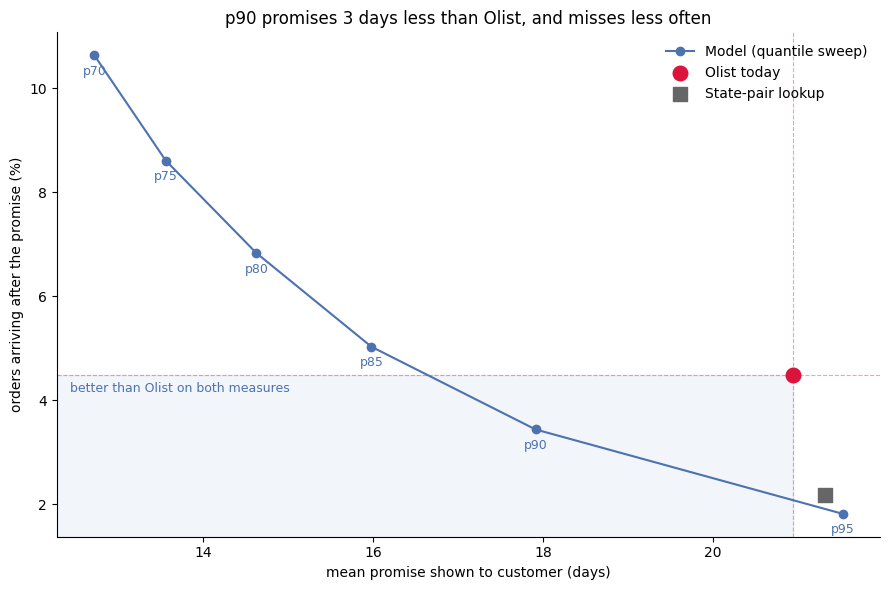

In [54]:
alphas = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
sweep = []

for a in alphas:
    m = LGBMRegressor(objective='quantile', alpha=a, verbose=-1, **BEST_PARAMS)
    m.fit(train_X, train_y)
    p = np.ceil(m.predict(test_X))
    sweep.append({'alpha': a,
                  'late_rate': (test_y.values > p).mean() * 100,
                  'mean_promise': p.mean()})

sweep = pd.DataFrame(sweep)

olist_late    = (comp.delivered_in_days > comp.estimated_delivery_days).mean() * 100
olist_promise = comp.estimated_delivery_days.mean()
base_late     = (comp.delivered_in_days > comp.baseline_pred_p90).mean() * 100
base_promise  = comp.baseline_pred_p90.mean()

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sweep.mean_promise, sweep.late_rate, '-o', color='#4c72b0',
        zorder=3, label="Model (quantile sweep)")
for _, r in sweep.iterrows():
    ax.annotate(f"p{int(r.alpha*100)}", (r.mean_promise, r.late_rate),
                textcoords="offset points", xytext=(0, -14),
                fontsize=9, ha='center', color='#4c72b0')

ax.scatter(olist_promise, olist_late, color='crimson', s=110, zorder=5,
           label="Olist today")
ax.scatter(base_promise, base_late, color='#666666', s=110, marker='s',
           zorder=5, label="State-pair lookup")

ax.axhline(olist_late, color='crimson', ls='--', lw=0.8, alpha=0.4)
ax.axvline(olist_promise, color='crimson', ls='--', lw=0.8, alpha=0.4)

x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
ax.add_patch(plt.Rectangle((x0, y0), olist_promise - x0, olist_late - y0,
                           color='#4c72b0', alpha=0.07, zorder=0))
ax.text(x0 + 0.15, olist_late - 0.15, "better than Olist on both measures",
        fontsize=9, color='#4c72b0', va='top')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)

ax.set(title="p90 promises 3 days less than Olist, and misses less often",
       xlabel="mean promise shown to customer (days)",
       ylabel="orders arriving after the promise (%)")
ax.legend(frameon=False, loc='upper right')
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "promise_vs_reliability.png"),
            dpi=200, bbox_inches='tight')

> **Findings:**
>
> Different alpha levels trade off one gain against another. on p70 we gain the shortest delivery estimates among others (~11 days in average) but we increase late rate a lot - >10%! The same but reversed one for p95.
>
> I chose and recommend p90 as one of the most optimal options which lowers both metrics.

> **But we also have some limitations:**
>
> * **Quiet test window.** Train includes two peak seasons, test (June–Oct 2018) has none, so any rule looks better here than it would over a full year.
> * **Right-censoring.** Orders from Sept–Oct still undelivered at the data cutoff are absent, making the tail months look faster.
> * **Straight-line distance.** Haversine understates real road travel, unevenly across routes.
> * **Freight may leak.** If freight is priced off Olist's own estimate, the model isn't fully independent of what it replaces.
> * **No conversion data.** Completed orders only, so the value of a shorter promise can't be priced.
> * **Tuned at one quantile.** BEST_PARAMS was selected at alpha 0.9, so other sweep points are slightly disadvantaged.


---

### Saving the model for later usage:

In [55]:
model.booster_.save_model(os.path.join(MODELS_DIR, "delivery_p90.txt"))

In [56]:
meta = {
    "model_files": {
        "native": "models/delivery_p90.txt"
    },
    "target": target,
    "features": model_features,
    "categorical_features": ["customer_state", "seller_state", "order_purchase_month"],
    "category_levels": {
        c: sorted(train_X[c].cat.categories.tolist())
        for c in ["customer_state", "seller_state", "order_purchase_month"]
    },
    "params": model.get_params(),
    "train_cutoff": str(cutoff),
    "n_train": int(len(train_X)),
    "n_test": int(len(test_X)),
    "test_metrics": {
        "late_rate_pct": round(float((test_y.values > comp.model_preds).mean() * 100), 2),
        "mean_promise_days": round(float(comp.model_preds.mean()), 2),
        "olist_late_rate_pct": round(float((comp.delivered_in_days > comp.estimated_delivery_days).mean() * 100), 2),
        "olist_mean_promise_days": round(float(comp.estimated_delivery_days.mean()), 2),
    },
    "notes": "Predicts the 0.90 quantile of delivery days from purchase. "
             "Output is the promise date offset, not expected delivery time. "
             "Apply np.ceil to predictions. Rebuild categoricals using category_levels "
             "before predicting, or codes will not align.",
}

with open(os.path.join(MODELS_DIR, "delivery_p90_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

Then in production it's ran as something like this:

In [57]:
TEST_RUN = False

if TEST_RUN:
  import json, lightgbm as lgb, pandas as pd, numpy as np

  new_orders = orders_agg.sample(frac=1/3) # using orders_agg as example

  meta = json.load(open(os.path.join(MODELS_DIR, "delivery_p90_meta.json")))
  booster = lgb.Booster(model_file=os.path.join(MODELS_DIR, "delivery_p90.txt"))

  X = new_orders[meta["features"]].copy()  # assuming new_orders is new dataframe of orders with essential features (which i pasted them again below)
  for c in meta["categorical_features"]:
      X[c] = pd.Categorical(X[c], categories=meta["category_levels"][c])

  promise_days = np.ceil(booster.predict(X))
  print(promise_days)

The model predicts days till order is delivered starting from purchase date, so for ready date estimate we do something like:

`promise_date = order_purchase_timestamp + pd.to_timedelta(predicted_days, unit='D')`

---

## *Testing the **model:***

In [58]:
# a randomly drawn test order, not a hand-picked one
row = comp.sample(1, random_state=142).iloc[0]

print(f"{row.seller_state} -> {row.customer_state}, {row.distance_km:.0f} km, "
      f"purchased {row.order_purchase_timestamp:%d %b %Y}\n")
print(f"Olist promised : {row.estimated_delivery_days:>3.0f} days  "
      f"({row.order_purchase_timestamp + pd.Timedelta(days=row.estimated_delivery_days):%d %b})")
print(f"Model promises : {row.model_preds:>3.0f} days  "
      f"({row.order_purchase_timestamp + pd.Timedelta(days=row.model_preds):%d %b})")
print(f"Actually took  : {row.delivered_in_days:>3.0f} days  "
      f"({row.order_delivered_customer_date:%d %b})")
print(f"\nPromise shortened by {row.estimated_delivery_days - row.model_preds:.0f} days, "
      f"still met by {row.model_preds - row.delivered_in_days:.0f} days.")

SP -> SP, 400 km, purchased 13 Aug 2018

Olist promised :  17 days  (30 Aug)
Model promises :  14 days  (27 Aug)
Actually took  :   7 days  (20 Aug)

Promise shortened by 3 days, still met by 7 days.
